Question 1 : The search should be optimal for worst-case scenario, here the worst case would be when the thing we are searching for is at the end of tree. In the original BST class, if we have keys which are in increasing or decreasing order, we will just end up with one child, basically making a list. In that case, we can sort the list and then select the middle value of the list and use that as parent, and do this recursively as mentioned in hint1 (similar to binary search).

In [63]:
class Node:

    def __init__(self, key, val, N):
        self.key = key
        self.val = val
        self.N = N
        self.left = None
        self.right = None

class BST:

    def __init__(self):
        self.root = None

    def size(self):
        return self._size(self.root)

    def _size(self, x):
        if x is None:
            return 0

        return x.N

    def get(self, key):
        return self._get(self.root, key)

    def _get(self, x, key):
        if x is None:
            return

        if x.key > key:
            return self._get(x.left, key)
        elif x.key < key:
            return self._get(x.right, key)
        else:
            return x.val

    def put(self, key, val):
        self.root = self._put(self.root, key, val)

    def _put(self, x, key, val):
        if x is None:
            return Node(key, val, 1)
        if x.key > key:
            x.left = self._put(x.left, key, val)
        elif x.key < key:
            x.right = self._put(x.right, key, val)
        else:
            x.val = val
        x.N = self._size(x.left) + self._size(x.right) + 1
        return x

    def delete(self, key):
        self.root = self._delete(self.root, key)

    def _delete(self, x, key):
        if x is None:
            return None

        if x.key > key:
            x.left = self._delete(x.left, key)
        elif x.key < key:
            x.right = self._delete(x.right, key)
        else:
            if x.right is None:
                return x.left
            if x.left is None:
                return x.right
            t = x
            x = self._min(t.right)
            x.right = self._deleteMin(t.right)
            x.left = t.left

        x.N = self._size(x.left) + self._size(x.right) + 1
        return x

    def delete_min(self):
        self.root = self._deleteMin(self.root)

    def _deleteMin(self, x):
        if x.left is None:
            return x.right
        x.left = self._deleteMin(x.left)
        x.N = self._size(x.left) + self._size(x.right) + 1
        return x

    def is_empty(self):
        return self.root is None

    def in_order(self):
        return self._inorder(self.root)

    def _inorder(self, root):
        if root is None:
            return []
        return self._inorder(root.left) + [root.key]+self._inorder(root.right)
    """
    The code till here is from the file attached with Homework 5.
    We breakdown the list in two halves at the midpoint, and this is done recursively. 
    """
    
    def reshape(self):
        sorted_list = self.in_order() #contains keys
        sorted_values = [self.get(key) for key in sorted_list]
        self.root  = self.reshaper(sorted_list,sorted_values)
        return self.root
        
    def reshaper(self,sorted_list,sorted_values):
        if len(sorted_list) == 0 :
            return 
        midpoint = len(sorted_list)//2 
        #this will be our new node
        new = Node(sorted_list[midpoint],sorted_values[midpoint],1) 
        #we can take this as left and right as the list is by default sorted in ascending order
        new.left = self.reshaper(sorted_list[:midpoint],sorted_values[:midpoint])
        new.right = self.reshaper(sorted_list[midpoint+1:],sorted_values[midpoint+1:]) # +1 so we  don't include midpoint
        new.N = 1 + self._size(new.left) + self._size(new.right)
        return new 
    """
    Following is Question 2 solution, I added it here to verify if my code for Question 1 is correct.
    """
    
    def getKeysAtDepth(self,d):
        key_value_list = []
        self.getKeysrecursion(self.root, d, 0 , key_value_list)
        return key_value_list
    
    def getKeysrecursion(self, node, d , level, key_value_list ):
        if node is None: #this is when recursion stops
            return 
        if level == d :
            key_value_list.append((node.key, node.val))
        else:
            """
            If our current_step value is not equal to d, we then move to left and right of the node and also increase the
            current_step value by 1.
            """
            self.getKeysrecursion(node.left, d , level + 1, key_value_list )
            self.getKeysrecursion(node.right, d , level + 1, key_value_list )

To check if the reshaper worked or not, we can run the function that gets keys at given depth from question 2 and see. Without it we should get just one key and with it will be more than one key at some depth (unless root). The idea here is that if we sort the list we should be gettting only one key at depth 2 which is shown by st1 object, st is just to show how it usually looks at depth 2, now we apply the reshape function on a new object st3 (all objects are same with "ighmqlcaz")  and see the keys at depth 2, as this reshape will automatically sort and then reshape the tree, which is evident. We can conclude that the reshape function works.

In [66]:
if __name__ == '__main__':
    st = BST()
    st1 = BST()
    
    for key in "ighmqlcaz".upper():
        st.put(key, ord(key) - ord('A'))
        
    print(f"Keys at depth 2 without sorting : {st.getKeysAtDepth(2)}") #without sorting
    
    list = []
    for i in "ighmqlcaz".upper():
        list.append(i)
    #print(list)
    list.sort()
    #print(list) 
    for key in list :
        st1.put(key, ord(key) - ord('A'))
    print(f"Keys at depth 2 with sorting : {st1.getKeysAtDepth(2)}") #with sorting

Keys at depth 2 without sorting : [('C', 2), ('H', 7), ('L', 11), ('Q', 16)]
Keys at depth 2 with sorting : [('G', 6)]


In [67]:
st3 = BST()
for key in "ighmqlcaz".upper():
        st3.put(key, ord(key) - ord('A'))
st3.reshape()
print(f"Keys at depth 2 with sorting followed by reshape function: {st3.getKeysAtDepth(2)}")

Keys at depth 2 with sorting followed by reshape function: [('C', 2), ('H', 7), ('M', 12), ('Z', 25)]


Question 2 :
The goal is to generate a function that get all key-value pairs at a given depth. First we start with a function that calls a recursive function, the base case would be depth d = 0, that is at root. The recursive fucntion  in one run will check if current depth is equal to d, if it is it will append key-value pair to an empty list. If not, it will go to left and right and does the same, at the end we will have all the key-value pairs in a list.



In [61]:
class Node:

    def __init__(self, key, val, N):
        self.key = key
        self.val = val
        self.N = N
        self.left = None
        self.right = None

class BST:

    def __init__(self):
        self.root = None

    def size(self):
        return self._size(self.root)

    def _size(self, x):
        if x is None:
            return 0

        return x.N

    def get(self, key):
        return self._get(self.root, key)

    def _get(self, x, key):
        if x is None:
            return

        if x.key > key:
            return self._get(x.left, key)
        elif x.key < key:
            return self._get(x.right, key)
        else:
            return x.val

    def put(self, key, val):
        self.root = self._put(self.root, key, val)

    def _put(self, x, key, val):
        if x is None:
            return Node(key, val, 1)
        if x.key > key:
            x.left = self._put(x.left, key, val)
        elif x.key < key:
            x.right = self._put(x.right, key, val)
        else:
            x.val = val
        x.N = self._size(x.left) + self._size(x.right) + 1
        return x

    def delete(self, key):
        self.root = self._delete(self.root, key)

    def _delete(self, x, key):
        if x is None:
            return None

        if x.key > key:
            x.left = self._delete(x.left, key)
        elif x.key < key:
            x.right = self._delete(x.right, key)
        else:
            if x.right is None:
                return x.left
            if x.left is None:
                return x.right
            t = x
            x = self._min(t.right)
            x.right = self._deleteMin(t.right)
            x.left = t.left

        x.N = self._size(x.left) + self._size(x.right) + 1
        return x

    def delete_min(self):
        self.root = self._deleteMin(self.root)

    def _deleteMin(self, x):
        if x.left is None:
            return x.right
        x.left = self._deleteMin(x.left)
        x.N = self._size(x.left) + self._size(x.right) + 1
        return x

    def is_empty(self):
        return self.root is None

    def in_order(self):
        return self._inorder(self.root)

    def _inorder(self, root):
        if root is None:
            return []
        return self._inorder(root.left) + [root.key]+self._inorder(root.right)
    
    """
    The code till here is from the file attached with Homework 5
    """

    def getKeysAtDepth(self,d):
        key_value_list = []
        self.getKeysrecursion(self.root, d, 0 , key_value_list)
        return key_value_list
    
    def getKeysrecursion(self, node, d , level, key_value_list ):
        if node is None: #this is when recursion stops
            return 
        if  level== d :
            key_value_list.append((node.key, node.val))
        else:
            """
            If our current_step value is not equal to d, we then move to left and right of the node and also increase the
            current_step value by 1.
            """
            self.getKeysrecursion(node.left, d , level + 1, key_value_list )
            self.getKeysrecursion(node.right, d , level + 1, key_value_list )


In [62]:
if __name__ == '__main__':
    st = BST()

    for key in "ighmqlcaz".upper():
        st.put(key, ord(key) - ord('A'))
    """
    Here, for loop will iterate through the given string. first key will take value of I, then we add ('I', ord(key)-ord('A')). Order of function
    converts characters to unicode points (numbers). So, we add (I, 8), then iterating variable will take g and so on...
    """
    print(f"Key-value pairs at depth 2 from left to right : {st.getKeysAtDepth(2)}") 


Key-value pairs at depth 2 from left to right : [('C', 2), ('H', 7), ('L', 11), ('Q', 16)]


Question 5 : 
My idea is, we can use the function getKeysAtDepth from Question 2 and run it in a for loop over all the levels and append them to get a list with bottom-up traversal.

In [7]:
class Node:

    def __init__(self, key, val, N):
        self.key = key
        self.val = val
        self.N = N
        self.left = None
        self.right = None

class BST:

    def __init__(self):
        self.root = None

    def size(self):
        return self._size(self.root)

    def _size(self, x):
        if x is None:
            return 0

        return x.N

    def get(self, key):
        return self._get(self.root, key)

    def _get(self, x, key):
        if x is None:
            return

        if x.key > key:
            return self._get(x.left, key)
        elif x.key < key:
            return self._get(x.right, key)
        else:
            return x.val

    def put(self, key, val):
        self.root = self._put(self.root, key, val)

    def _put(self, x, key, val):
        if x is None:
            return Node(key, val, 1)
        if x.key > key:
            x.left = self._put(x.left, key, val)
        elif x.key < key:
            x.right = self._put(x.right, key, val)
        else:
            x.val = val
        x.N = self._size(x.left) + self._size(x.right) + 1
        return x

    def delete(self, key):
        self.root = self._delete(self.root, key)

    def _delete(self, x, key):
        if x is None:
            return None

        if x.key > key:
            x.left = self._delete(x.left, key)
        elif x.key < key:
            x.right = self._delete(x.right, key)
        else:
            if x.right is None:
                return x.left
            if x.left is None:
                return x.right
            t = x
            x = self._min(t.right)
            x.right = self._deleteMin(t.right)
            x.left = t.left

        x.N = self._size(x.left) + self._size(x.right) + 1
        return x

    def delete_min(self):
        self.root = self._deleteMin(self.root)

    def _deleteMin(self, x):
        if x.left is None:
            return x.right
        x.left = self._deleteMin(x.left)
        x.N = self._size(x.left) + self._size(x.right) + 1
        return x

    def is_empty(self):
        return self.root is None

    def in_order(self):
        return self._inorder(self.root)

    def _inorder(self, root):
        if root is None:
            return []
        return self._inorder(root.left) + [root.key]+self._inorder(root.right)
    
    """
    The code till here is from the file attached with Homework 5
    """

    def getKeysAtDepth(self,d):
        key_value_list = []
        self.getKeysrecursion(self.root, d, 0 , key_value_list)
        return key_value_list
    
    def getKeysrecursion(self, node, d , level, key_value_list ):
        if node is None: 
            return 
        if  level== d :
            key_value_list.append((node.key, node.val))
        else:
            """
            If our current_step value is not equal to d, we then move to left and right of the node and also increase the
            current_step value by 1.
            """
            self.getKeysrecursion(node.left, d , level + 1, key_value_list )
            self.getKeysrecursion(node.right, d , level + 1, key_value_list )

    """
    Following is solution to Question 3
    """
    def levels(self):
        return self.rlevels(self.root)
    
    def rlevels(self,node):
        if node is None:
            return 0
        #if we have nodes left it will keep on going further lower.
        return max(self.rlevels(node.left), self.rlevels(node.right))+1 #)
    
    def bottom_up_traversal(self):
        maxdepth = self.levels()
        reversed_list = []
        reversed_list.extend((self.getKeysAtDepth(maxdepth-1)))
        #here, we start from maxdepth-1 (as depth starts with zero), we go to -1 as end is exclusive in range
        for d in range(maxdepth-2, -1, -1): 
            reversed_list.extend((self.getKeysAtDepth(d))[::-1])
        return reversed_list

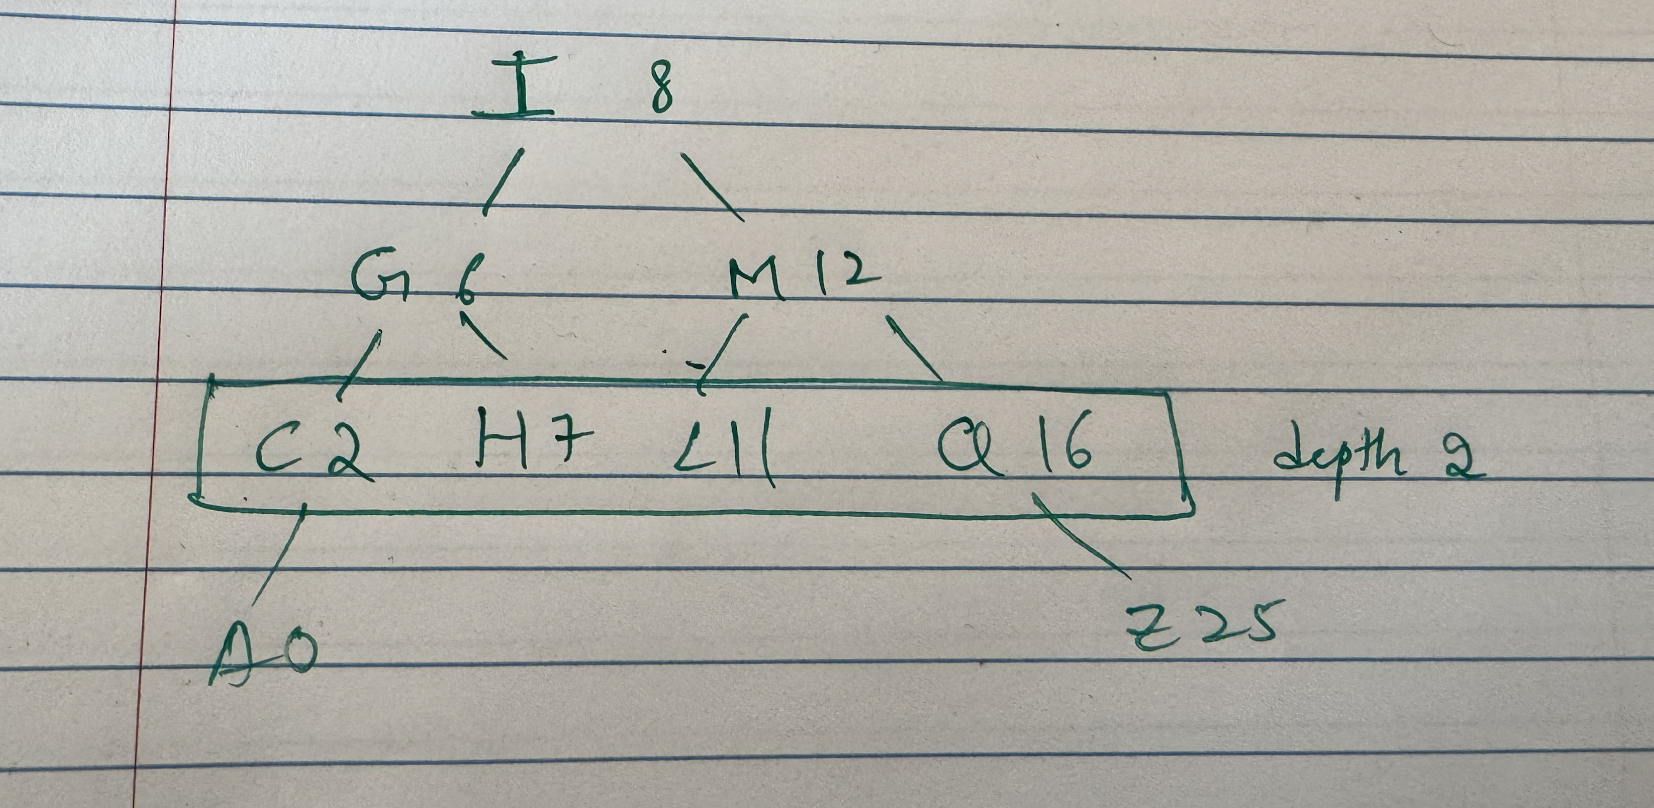

In [90]:
from IPython.display import Image, display
img_path = "image.png"  
display(Image(filename=img_path))

In [8]:
if __name__ == '__main__':
    but = BST()
    
    for key in "ighmqlcaz".upper():
        but.put(key, ord(key) - ord('A'))
        
    print(f"Bottom-up traversal: {but.bottom_up_traversal()}")
    #this is as expected for above tree, it's similar to what was shown in question

Bottom-up traversal: [('A', 0), ('Z', 25), ('Q', 16), ('L', 11), ('H', 7), ('C', 2), ('M', 12), ('G', 6), ('I', 8)]


For bottom_up_traversal function, here the worst case would be to visit each node when the keys are in ascending or descending order. But we neeed to visit each node anyway, so it have time complexity O(n), where n is number of nodes. One for each node.
For space complexity also worst case is O(n) as all the times space is used like in the tree, in recursion of getkeysatdepth function, the space is proportional to n, making the final space complexity O(n) 
